## Задание 

Вам нужно провести эксперимент с моделями класса MA, над стационарным и нестационарным рядом, чтобы определить какая из моделей в данном случае оптимальна.

Инструкция к выполнению

- Возьмите 2 ряда из материалов: стационарный и нестационарный.
- Постройте прогноз для каждого с помощью каждой из моделей: MA, EMA, DEMA, TEMA
- Оцените качество (метрика регрессии на ваш выбор MAE, MSE, RMSE), подобрав оптимальные параметры на первых месяцах ряда и спрогнозировав на последний, сравнив с истинными предсказаниями;
- Определите оптимальную модель для каждого ряда и обоснуйте свой выбор.

### Загрузка данных и создание основных функций для предсказаний

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from itertools import product ## для создания весов



In [6]:
sales_of_company_x = pd.read_csv("/Users/sofagusina/Desktop/код/machine_learning/machine_learning/ML/Временные ряды/Элементарные методы анализа временных рядов/Материалы к занятию «Знакомство с временными рядами»/Series/monthly-sales-of-company-x-jan-6.csv")

female_births = pd.read_csv("/Users/sofagusina/Desktop/код/machine_learning/machine_learning/ML/Временные ряды/Элементарные методы анализа временных рядов/Материалы к занятию «Знакомство с временными рядами»/Series/daily-total-female-births-in-cal.csv")

In [7]:
sales_of_company_x

,Month,Count
0,1965-01,154
1,1965-02,96
2,1965-03,73
3,1965-04,49
4,1965-05,36
...,...,...
72,1971-01,628
73,1971-02,308
74,1971-03,324
75,1971-04,248


#### Модель MA

In [8]:
def moving_average(series,n_window,n_preds):
    if not isinstance(series,pd.Series):
        series = pd.Series(series)

    series_copy = series.copy()
    for _ in range(n_preds):
        next_val = series_copy[-n_window:].mean() ## предсказанное значение - результат среднего предыдущих значений внутри окна
        next_val_series = pd.Series([next_val])
        series_copy = pd.concat([series_copy, pd.Series([next_val])], ignore_index=True) 
    return series_copy

#### Модель WMA со взвешенным скользящим средним

In [9]:
def moving_average_weight(series,n_window,weight,n_preds):
    if not isinstance(series,pd.Series):
        series = pd.Series(series)
    if not isinstance(weight, np.ndarray):
        weight = np.array(weight)
    
    series_copy = series.copy()
    weight = weight / weight.sum()
    
    # wma = series.rolling(n_window).apply(lambda x: (x*weight).sum()/weight.sum(),raw=True) ## raw=True - строка серии передастся как массив np

    for _ in range(n_preds):
        last_vals = series_copy.iloc[-n_window:].to_numpy()
        next_val = np.dot(last_vals, weight)  # умножаем матрицу значений на
        series_copy = pd.concat([series_copy, pd.Series([next_val])], ignore_index=True)

    return series_copy



#### Модель EMA

In [10]:
def moving_average_exp(series,alpha,n_preds):
    series = pd.Series(series)
    result = [series.iloc[0]]
    
    # сглаживание
    for n in range(1, len(series)):
        result.append(alpha * series.iloc[n] + (1 - alpha) * result[n-1])
    
    result_series = pd.Series(result)
    
    if not n_preds:
        return result_series
    
    # прогноз на n_pred шагов — просто последний сглаженный элемент
    predictions = pd.Series([result[-1]] * n_preds)
    extended_series = pd.concat([series, predictions], ignore_index=True)
    
    return extended_series

#### Модель DEMA

In [55]:
def moving_average_dooble_exp(series,betta,alpha,n_preds):
    if not isinstance(series,pd.Series):
        series = pd.Series(series)

    result = [series[0]]
    level = series.iloc[0]
    trend = series.iloc[1] - series.iloc[0]

    for n in range(1,len(series)): ## сглаживаем ряд
        value = series.iloc[n]
        last_level = level
        level = (alpha*value) + (1-alpha)*(level+trend)
        trend = betta*(level - last_level) + (1-betta)*trend
        result.append(level+trend)

    preds = []

    for n in range(n_preds): ## делаем предсказания
        value = result[-1]
        last_level = level
        level = (alpha*value) + (1-alpha)*(level+trend)
        trend = betta*(level - last_level) + (1-betta)*trend
        result.append(level+trend)
        preds.append(level+trend)
    
    series_new = pd.concat([series, pd.Series(preds)], ignore_index=True)
    
    return series_new
    



#### Модель TEMA

In [186]:
## оценка начальных значений сезонности - создание поправки на сезонность
def initial_seasonal_components(series, n): 
    seasonals = [] ## словарь сезонной поправки для значений внутри сезона
    season_averages = []
    n_seasons = int(len(series)/n)
    # compute season averages
    for j in range(n_seasons):
        ## счет среднего значения по срезу и доавление его в массив
        season_averages.append(sum(series[n*j:n*j+n])/float(n)) ## берем срез из серии, где начальный индекс - число сезонов*размер сезона, конечный - число сезонов*размер сезона - число сезонов

    for i in range(n): ## для каждого значения в сезоне (1 элемент в 1 сезоне, 1 элемент во 2 сезоне ...)
        sum_of_vals_over_avg = 0.0
        for j in range(n_seasons): ## для каждого сезона
            ## показывает, насколько (в среднем по сезонам) значение в позиции i отклоняется от средней по своему сезону.
            sum_of_vals_over_avg += series[n*j+i]-season_averages[j] ## Cкладываем отклонения значений этой позиции от среднего по соответствующему сезону.
        seasonals.append(sum_of_vals_over_avg / n_seasons) ## считаем отклонения от среднего значения в сезоне
    
    return seasonals ## возвращем словарь отклонений каждого значения в сезоне от среднего значения по сезону

In [11]:
# series = [10,20,30, 40,50,60, 70,80,90] 
# n = 3

# initial_seasonal_components(series=series,n=n)

# n_seasons = 9//3 = 3
# season_averages = [(10+20+30)/3, (40+50+60)/3, (70+80+90)/3] = [20, 50, 80]

# i=0:
# (10-20) + (40-50) + (70-80) = -10 + -10 + -10 = -30
# seasonals[0] = -30 / 3 = -10

# i=1:
# (20-20) + (50-50) + (80-80) = 0 → seasonals[1] = 0

# i=2:
# (30-20) + (60-50) + (90-80) = 10+10+10 = 30 → seasonals[2] = 10

# Итог: seasonals = {0:-10.0, 1:0.0, 2:10.0}


In [180]:
## оценка начальных значений тренда
def initial_trend(series, season_len):
    trend = 0.0
    for i in range(season_len):
        trend += (series[i + season_len] - series[i]) / season_len
    return trend / season_len

In [181]:
def moving_average_tripple_exp(series,n_season,alpha,beta,gamma,n_preds):
    if not isinstance(series,pd.Series):
        series = pd.Series(series)
    result =  []
    season = initial_seasonal_components(series,n_season)
    level = series[0]
    trend = initial_trend(series, n_season)

    for i in range(len(series) + n_preds): ## число i - от 0 до размера длины серии+длины предсказаний
        ## устанавливаем начальные значений
        
        if i >=len(series): ## если перешли за серию, то делаем прогноз
            m = i - len(series) + 1 ## на  столько шагов вперед будем проецировать тренд
            result.append((level + m*trend) + season[i % n_season]) ## делаем прогноз точки, season[i%n] - берет поправку на сезонность, например, i=10, количество сезонов - 3, тогда поправка возбмется из словаря для ключа 1
        
        else: ## сглаживаем ряд 
            val = series[i]
            last_level = level
            level = alpha*(val-season[i % n_season]) + (1-alpha)*(level+trend)
            trend = beta * (level-last_level) + (1-beta)*trend
            season[i % n_season] = gamma*(val-level) + (1-gamma)*season[i % n_season]
            result.append(level+trend+season[i % n_season])

    series_new = pd.concat([pd.Series(result)], ignore_index=True)
    return series_new




0     154.000000
1      74.694444
2     -14.879583
3     -43.169079
4     -52.751268
         ...    
74    473.651881
75    418.407630
76    371.608553
77    340.476786
78    364.725752
Length: 79, dtype: float64

In [14]:
# n_preds = 5
# series = [1,2,3,4]
# for i in range(len(series) + n_preds):
#     print(i)

#### Подбор параметров


Подбираем параметры на первых месяцах ряда и смотрим ошибку на последнем месяце.

In [12]:
def train_test_val_split(series):
    train,test = series[:76], series[76:]
    return train, test

Для модели MA

In [13]:
def moving_average_mse(series):
    errors = {}

    for window in range(1,70):
        train, test = train_test_val_split(series)

        result = moving_average(series=train,n_window=window,n_preds=len(test)) 
        preds = result[-len(test):]

        error = mean_squared_error(preds,test)
        errors[window] = error
        
    opt_window = min(errors, key = errors.get)
    print(f'Оптимальное окно - {opt_window}, ошибка MSE - {errors[opt_window]}')


Для модели WMA

Простой перебор весов

In [31]:
def optimize_weight_overkill(series,n_window, scale_factor):
    
    train, test = train_test_val_split(series)

    ### Задаем автоматический подбор диапазона весов, которые будут генерироваться для подбора
    max_val = max(train)  # можно заменить на среднее или стандартное отклонение
    max_weight = max(1, int(max_val * scale_factor)) ## scale_factor будем менять, как значение весов зависят от максимального значения ряда
    weight_range = range(1, max_weight + 1)

    weight_combinations = product(weight_range, repeat=n_window) ## задаем комбинацию
    best_error = np.inf ## задаем начальную лучшую ошибку - бесконечность
    best_weights = None
    
    for weights in weight_combinations:
        weights = np.array(weights)
        series_copy = train.copy()
        for _ in range(len(test)):
            result = moving_average_weight(series=series_copy,n_window=n_window,n_preds=len(test),weight=weights) 
            preds = result[-len(test):]

            error = mean_squared_error(preds,test)
        
        if error < best_error:
            best_error = error
            best_weights = weights/weights.sum()

        
    print(f"Оптимальные веса: {best_weights}, MSE: {best_error}")

Подбор весов с помощью градиентного спуска

In [15]:
def weight_moving_average_mse(weights,series,n_window):
    
    train, test = train_test_val_split(series)
    weights = np.array(weights)
    
    result = moving_average_weight(series=train,n_window=n_window,n_preds=len(test),weight=weights) 
    preds = result[-len(test):]

    error = mean_squared_error(preds,test)
    return error

In [16]:
def optimize_weights_wma_grad(series,n_window):
    x0 = np.ones(n_window) ## создаем стартовые веса - все единицы
    bounds = [(0, np.inf)] * n_window

    res = minimize(weight_moving_average_mse,x0=x0,args=(series,n_window),method="L-BFGS-B",bounds=bounds)

    print(f"Оптимальные веса: {res.x}, MSE - {res.fun}")
    return res.x


Будем пользоваться весами, подобранными с помощью метода градиентного спуска

Для модели EMA

In [17]:
def exp_moving_mse(alpha,series):
    alpha = alpha[0]
    train, test = train_test_val_split(series)
    
    
    result = moving_average_exp(series=train,alpha=alpha,n_preds=len(test)) 
    preds = result[-len(test):]

    error = mean_squared_error(preds,test)
    return error

In [18]:
def optimize_exp_moving_param(series):
    x0 = np.array([0.3]) ## создаем стартовый вес - 0.3
    bounds = [(0, 1)]

    res = minimize(exp_moving_mse,x0=x0,args=(series,),method="L-BFGS-B",bounds=bounds)

    print(f"Оптимальное значение альфа: {res.x}, MSE - {res.fun}")
    return res.x

Дл модели DEMA

In [64]:
def double_exp_mse (params,series):
    alpha,betta = params
    train, test = train_test_val_split(series)
    
    result = moving_average_dooble_exp(series=train,alpha=alpha,betta=betta,n_preds=len(test)) 
    preds = result[-len(test):]

    error = mean_squared_error(preds,test)
    return error


In [65]:
double_exp_mse([0.1,0.1],sales_of_company_x['Count'])

67540.93763581876

In [70]:
def optimize_double_exp_param(series):
    x0 = x0 = np.ones(2) * 0.1 ## создаем стартовые веса - 0.3
    bounds = [(0, 1),(0, 1)]

    res = minimize(double_exp_mse,x0=x0,args=(series,),method="L-BFGS-B",bounds=bounds)
    alpha_opt,betta_opt = res.x 

    print(f"Оптимальное значение альфа: {alpha_opt:.4f}, оптимальное значение бетта: {betta_opt:.4f}, MSE - {res.fun}")

По модели TEMA

In [176]:
def tripple_exp_mse(params,series,n_season):
    alpha,betta,gamma = params
    train, test = train_test_val_split(series)
    
    result = moving_average_tripple_exp(series=train,alpha=alpha,beta=betta,gamma=gamma,n_preds=len(test),n_season=n_season) 
    preds = result[-len(test):]

    error = mean_squared_error(preds,test)
    return error


In [238]:
def optimize_tripple_exp_param(series,n_season):
    x0 = np.ones(3) * 0.1 ## создаем стартовые веса - 0.3
    bounds = [(0, 1),(0, 1),(0, 1)]

    res = minimize(tripple_exp_mse,x0=x0,args=(series,n_season),method="L-BFGS-B",bounds=bounds)
    alpha_opt,betta_opt,gamma_opt = res.x 

    print(f"Оптимальное значение альфа: {alpha_opt:.4f}, оптимальное значение бетта: {betta_opt:.4f}, оптимальное значение бетта: {gamma_opt:.4f}, MSE - {res.fun}")

#### Кросс-валидация моделей

In [192]:
def cross_validation_model(params, train, model, n_window):
    params = np.atleast_1d(params).astype(float)

    # Разбор параметров по моделям
    if model == 'MA':
        n_window = int(round(params[0]))
    elif model == 'WMA':
        weight_arr = np.array(params)
    elif model == 'EMA':
        alpha = params[0]
    elif model == 'DEMA':
        alpha, beta = params
    elif model == 'TEMA':
        alpha, beta, gamma, n_season = params
        n_season = int(round(n_season))

    split = TimeSeriesSplit(n_splits=3)
    errors = []

    for train_idx, test_idx in split.split(train):
        train_split_ts = train.iloc[train_idx]
        test_split_ts = train.iloc[test_idx]

        if model == 'MA':
            result = moving_average(series=train_split_ts, n_window=n_window, n_preds=len(test_split_ts))
        elif model == 'WMA':
            result = moving_average_weight(series=train_split_ts, n_window=n_window,
                                           n_preds=len(test_split_ts), weight=weight_arr)
        elif model == 'EMA':
            result = moving_average_exp(series=train_split_ts, alpha=alpha, n_preds=len(test_split_ts))
        elif model == 'DEMA':
            result = moving_average_dooble_exp(series=train_split_ts, alpha=alpha, betta=beta,
                                               n_preds=len(test_split_ts))
        elif model == 'TEMA':
            result = moving_average_tripple_exp(series=train_split_ts, alpha=alpha, beta=beta,
                                                gamma=gamma, n_preds=len(test_split_ts),
                                                n_season=n_season)

        predictions = result[-len(test_split_ts):]
        error = mean_squared_error(test_split_ts, predictions)
        errors.append(error)

    return np.mean(errors)



In [206]:
def opt_val_param(model, n_window, X, train):
    match model:
        case 'MA':
            bounds = [(1, 50)]  # n_window, пусть от 1 до 50
            errors = []
            for w in range(2, 51):
                err = cross_validation_model([w], train, model, n_window=None)
                errors.append((w, err))
            best_w, best_err = min(errors, key=lambda x: x[1])
            return {"x": best_w, "fun": best_err}
        case 'WMA':
            bounds = [(0, np.inf)] * n_window  # веса
        case 'EMA':
            bounds = [(0, 1)]  # alpha
        case 'DEMA':
            bounds = [(0, 1), (0, 1)]  # alpha, beta
        case 'TEMA':
            bounds = [(0, 1), (0, 1), (0, 1), (2, 24)]  # alpha, beta, gamma, n_season
        

    opt = minimize(
        cross_validation_model,
        x0=X,
        args=(train, model, n_window),
        method="L-BFGS-B",  # поддерживает bounds
        bounds=bounds
    )
    return opt

#### Визуализация

In [21]:
def plot_(model,series,title):
    with plt.style.context('bmh'):
        plt.figure(figsize=(8, 8))
        plt.plot(model, color='red', linewidth='2', label='Pred')
        plt.plot(series, color='blue', linewidth='2', label='Real')
        plt.legend()
        plt.title(f'{title}')

    plt.show()

### Предсказание значений для нестационарного ряда

#### По модели MA

In [22]:
moving_average_mse(sales_of_company_x['Count'])

Оптимальное окно - 2, ошибка MSE - 196.0


In [187]:
train,test = train_test_val_split(sales_of_company_x['Count'])
ma = moving_average(train, n_window=2,n_preds=len(test))
len(train)

76

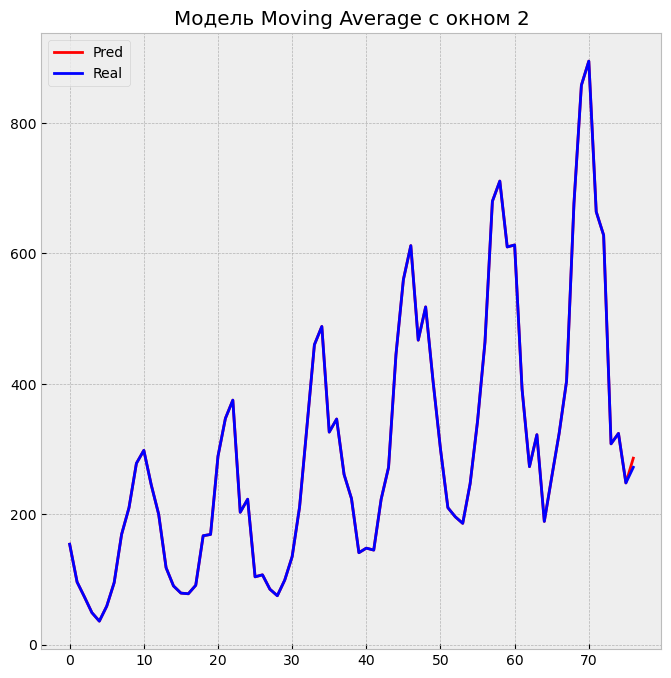

In [24]:
plot_(model=ma,series=sales_of_company_x['Count'],title=f'Модель Moving Average c окном 2')

Таким образом, средняя квартичная ошибка для модели скользящего среднего - 196 единиц.

#### По модели WMA

In [32]:
optimize_weight_overkill(sales_of_company_x['Count'],n_window=3,scale_factor=0.1)

Оптимальные веса: [0.08333333 0.25       0.66666667], MSE: 0.0


In [26]:
weight = optimize_weights_wma_grad(series=sales_of_company_x['Count'],n_window=2)

Оптимальные веса: [0.94326195 2.04373422], MSE - 2.3555813932501488e-15


Будем использовать веса, подобранные с помощью градиентного спуска

In [27]:
train,test = train_test_val_split(sales_of_company_x['Count'])

wma = moving_average_weight(train, n_window=2,n_preds=len(test),weight=weight)


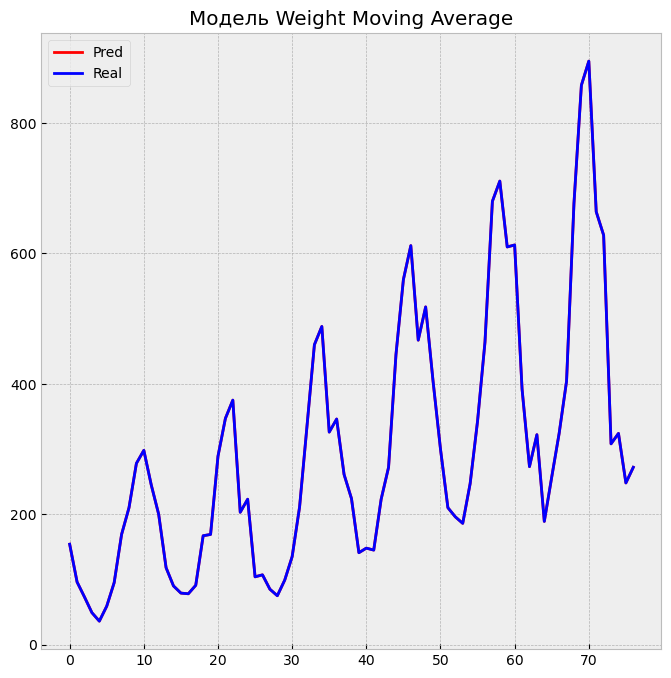

In [28]:
plot_(model = wma,series=sales_of_company_x['Count'],title='Модель Weight Moving Average')

Модель идеально предсказывает последнее значение ряда, посмотрим, как она предсказывает 10 значений вне ряда

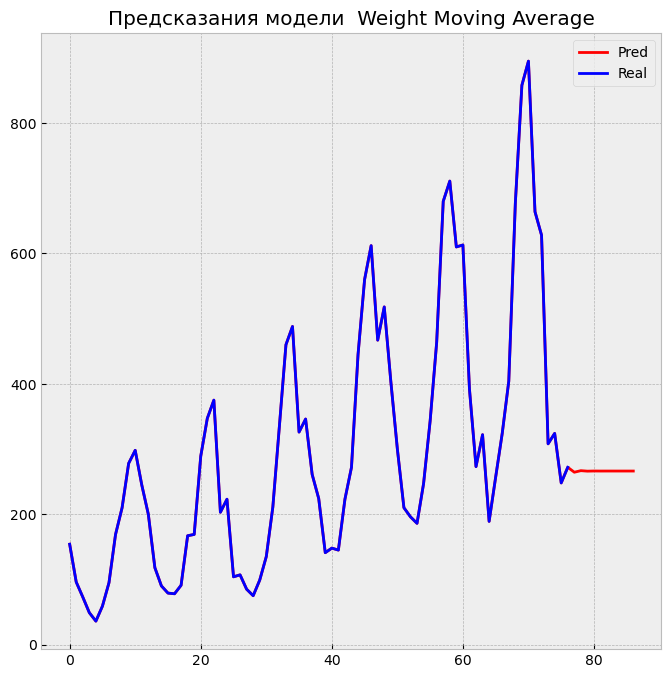

In [29]:
wma_pred = moving_average_weight(sales_of_company_x['Count'],n_window=2,n_preds=10,weight=weight)
plot_(model=wma_pred,series=sales_of_company_x['Count'],title='Предсказания модели  Weight Moving Average')

Предсказания выходят на один уровень

In [226]:
wma_pred[76:]

76    272.000000
77    264.421053
78    266.814404
79    266.058609
80    266.297281
81    266.221911
82    266.245712
83    266.238196
84    266.240570
85    266.239820
86    266.240057
dtype: float64

#### По модели EMA

In [261]:
optimize_exp_moving_param(series=sales_of_company_x['Count'])

Оптимальное значение альфа: [0.74513694], MSE - 3.3984973296709857e-13


array([0.74513694])

In [263]:
ema = moving_average_exp(series = train,alpha=0.745,n_preds=len(test))
ema

0     154.000000
1      96.000000
2      73.000000
3      49.000000
4      36.000000
         ...    
72    628.000000
73    308.000000
74    324.000000
75    248.000000
76    272.018726
Length: 77, dtype: float64

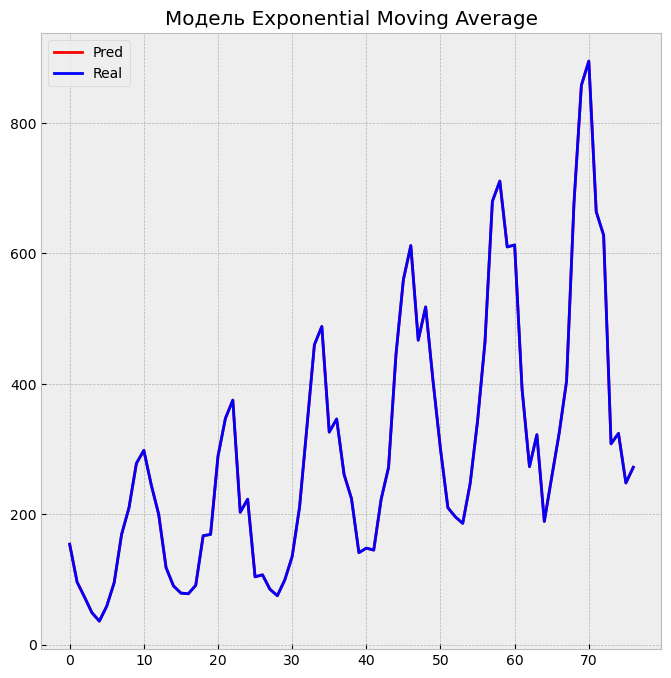

In [265]:
plot_(ema,sales_of_company_x['Count'],'Модель Exponential Moving Average')

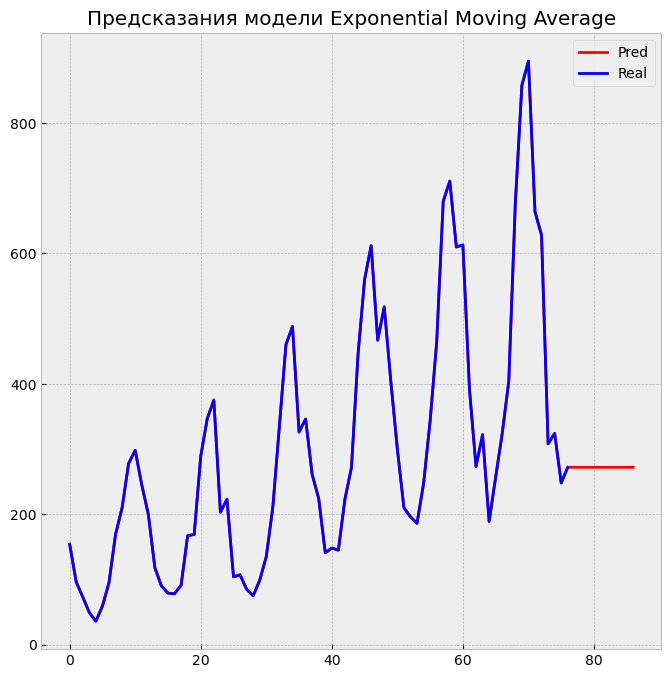

In [266]:
plot_(moving_average_exp(series = sales_of_company_x['Count'],alpha=0.745,n_preds=10),sales_of_company_x['Count'],'Предсказания модели Exponential Moving Average')

#### По модели DEMA

In [72]:
optimize_double_exp_param(series=sales_of_company_x['Count'])

Оптимальное значение альфа: 0.3407, оптимальное значение бетта: 0.3430, MSE - 4.2688708337587285e-11


In [73]:
dema = moving_average_dooble_exp(series=train,betta=0.343,alpha=0.3407,n_preds=len(test))

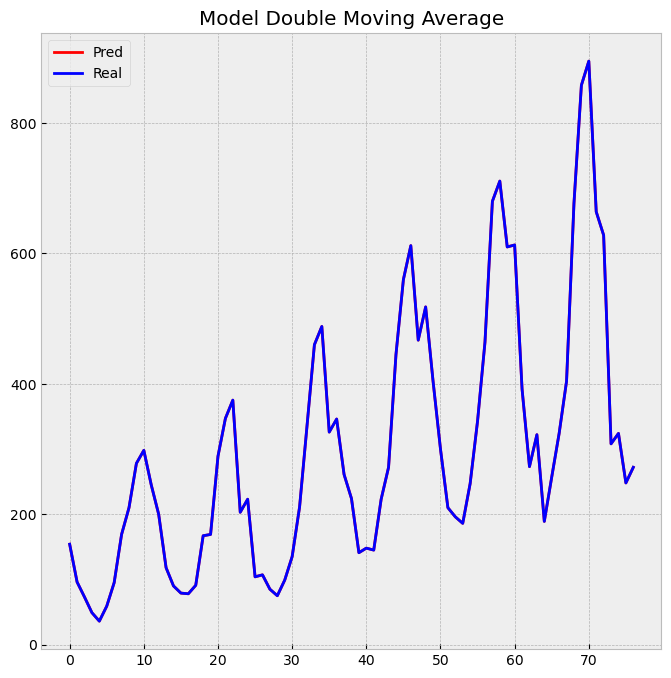

In [74]:
plot_(model=dema,series=sales_of_company_x['Count'],title='Model Double Moving Average')

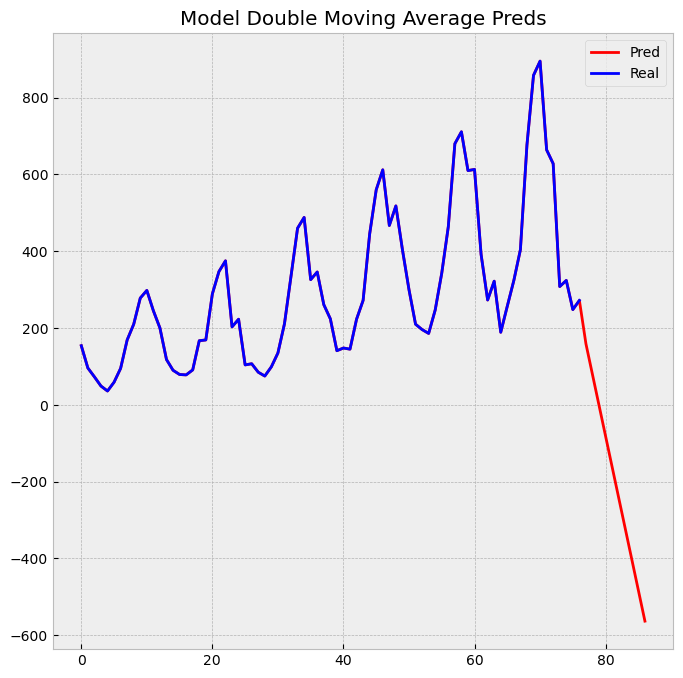

In [76]:
plot_(model=moving_average_dooble_exp(series=sales_of_company_x['Count'],betta=0.343,alpha=0.3407,n_preds=10),series=sales_of_company_x['Count'],title='Model Double Moving Average Preds')

Предсказания модели падают резко вниз, попробуем немного изменить параметры альфа и бетта

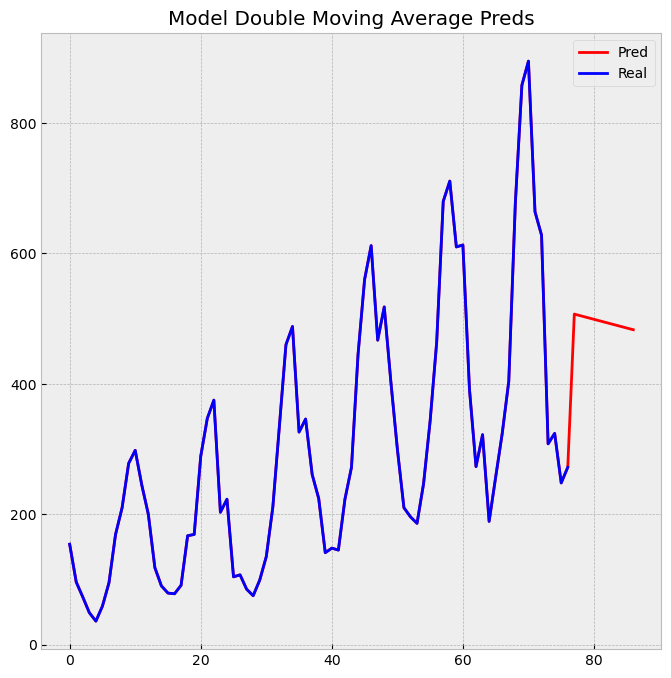

In [88]:
plot_(model=moving_average_dooble_exp(series=sales_of_company_x['Count'],betta=0.2,alpha=0.1,n_preds=10),series=sales_of_company_x['Count'],title='Model Double Moving Average Preds')

При уменьшении параметра альфа предсказания примерно продолжают ряд

#### По модели TEMA

In [239]:
optimize_tripple_exp_param(sales_of_company_x['Count'],n_season=12)

Оптимальное значение альфа: 0.2912, оптимальное значение бетта: 0.3004, оптимальное значение бетта: 0.3186, MSE - 2.466776788965407e-12


In [131]:
tema = moving_average_tripple_exp(series=train,n_season = 12,alpha=0.406,beta=0.0304,gamma=0.0727,n_preds=len(test))

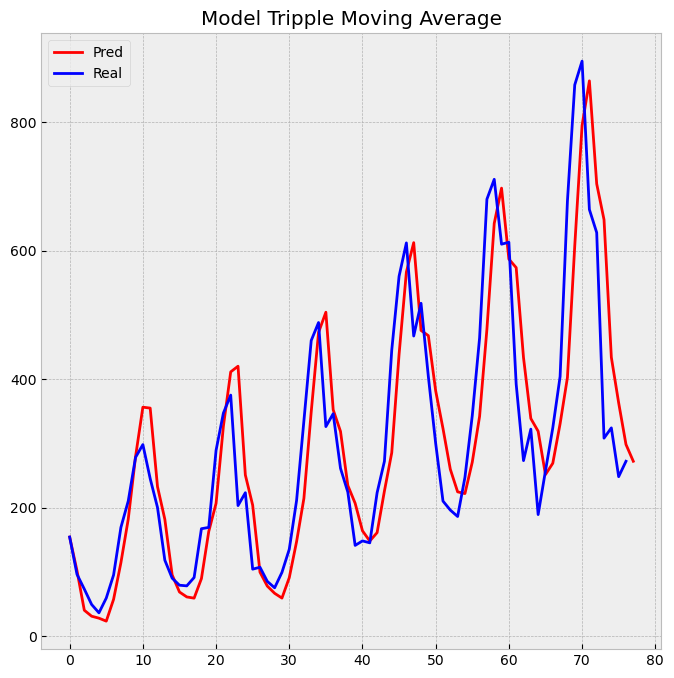

In [132]:
plot_(model=tema,series=sales_of_company_x['Count'],title = 'Model Tripple Moving Average')

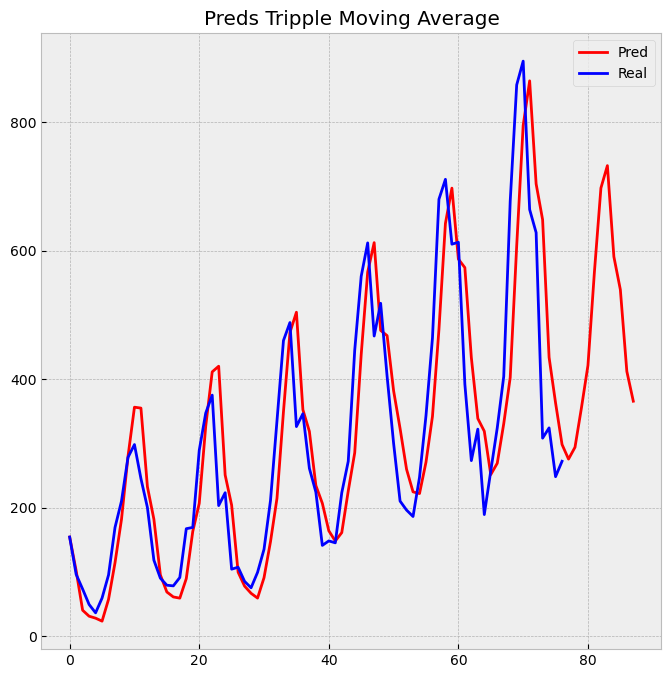

In [133]:
plot_(model=moving_average_tripple_exp(series=sales_of_company_x['Count'],n_season = 12,alpha=0.406,beta=0.0304,gamma=0.0727,n_preds=10),series=sales_of_company_x['Count'],title = 'Preds Tripple Moving Average')

Модель очень хорошо предсказывает ряд

#### Кросс-валидация моделей 

Moving Average

In [209]:
print(f'Оптимальный размер окна - {opt_val_param(model='MA',X=[1,],train=train,n_window=None)['x']}, ошибка MSE - {opt_val_param(model='MA',X=[1,],train=train,n_window=None)['fun']:.2f}')

Оптимальный размер окна - 2, ошибка MSE - 33462.90


Weight Moving Average

In [217]:
print(f'Оптимальные веса - {opt_val_param(model='WMA',X=[1,1],train=train,n_window=2).x[0],opt_val_param(model='WMA',X=[1,1],train=train,n_window=2).x[1]}, ошибка MSE - {opt_val_param(model='WMA',X=[1,1],train=train,n_window=2).fun:.2f}')


Оптимальные веса - (0.0, 2.7710693694098567), ошибка MSE - 31371.72


Exponential Moving Average

In [230]:
print(f'Оптимальное значение альфа- {opt_val_param(model='EMA',train=train,X=np.array([0.2]),n_window=None).x[0],}, ошибка MSE - {opt_val_param(model='EMA',train=train,X=np.array([0.2]),n_window=None).fun:.2f}')


Оптимальное значение альфа- (1.0,), ошибка MSE - 31371.72


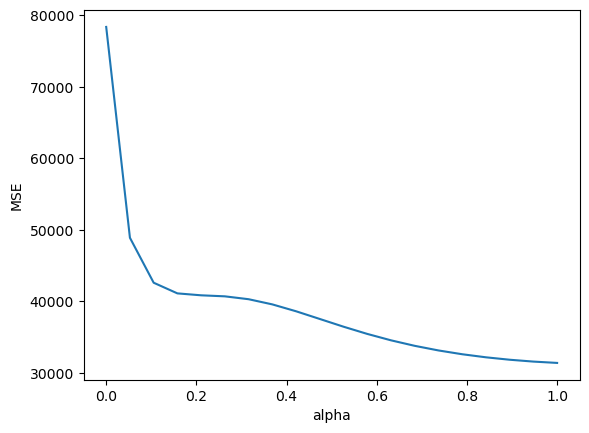

In [225]:
alphas = np.linspace(0, 1, 20)
errors = []
for a in alphas:
    err = cross_validation_model([a], train, 'EMA', n_window=None)
    errors.append(err)

import matplotlib.pyplot as plt
plt.plot(alphas, errors)
plt.xlabel('alpha')
plt.ylabel('MSE')
plt.show()

Double Exponential Moving Average

In [233]:
print(f'Оптимальное значение альфа- {opt_val_param(model='DEMA',X=[0.1,0.1],n_window=None,train=train).x[0]:.2f}, значение бетта -{opt_val_param(model='DEMA',X=[0.1,0.1],n_window=None,train=train).x[1]:.2f} ошибка MSE - {opt_val_param(model='DEMA',X=[0.1,0.1],n_window=None,train=train).fun:.2f}')


Оптимальное значение альфа- 0.62, значение бетта -0.16 ошибка MSE - 39908.21


Tripple Exponential Moving Average

In [235]:
opt_val_param(model='TEMA',n_window=None,X=[0.1,0.1,0.1,6],train=train)
print(f'Оптимальное значение альфа- {opt_val_param(model='TEMA',n_window=None,X=[0.1,0.1,0.1,6],train=train).x[0]:.2f}, значение бетта -{opt_val_param(model='TEMA',n_window=None,X=[0.1,0.1,0.1,6],train=train).x[1]:.2f}, значение гамма - {opt_val_param(model='TEMA',n_window=None,X=[0.1,0.1,0.1,6],train=train).x[2]:.2f}, ошибка MSE - {opt_val_param(model='TEMA',n_window=None,X=[0.1,0.1,0.1,6],train=train).fun:.2f}')


Оптимальное значение альфа- 0.08, значение бетта -0.14, значение гамма - 0.00, ошибка MSE - 29005.30


### Промежуточный вывод по моделям для нестационарного ряда

Вывод: в ходе работы были найдены оптимальные параметры для каждой модели - MA,WMA,EMA,DEMA и TEMA - и построены предсказания для нестационарного ряда. В связи с чем можно выделить, что лучше всего делает предсказания модель TEMA - она практически "продлевает ряд" согласно сезонности, уровню и тренду ряда, кроме того, данная модель имеет самую низкую ошибку MSE на валидационной и тестовой выборках среди всех моделей. Также была проведена кросс-валидация ряда, в ходе которой также удалось найти наилучшие параметры для каждой из моделей. Значения этих параметров существенно отличаются от значений, полученных на оптимизации моделей по первым месяцам ряда и оценки ошибки на последнем месяце. 

### Предсказание моделей для стационарного ряда

#### Для модели MA

In [249]:
moving_average_mse(female_births['Count'])

Оптимальное окно - 1, ошибка MSE - 51.29065743944636


In [245]:
train_stat,test_stat = train_test_val_split(female_births['Count'])
ma_stat = moving_average(train_stat, n_window=1,n_preds=len(test))

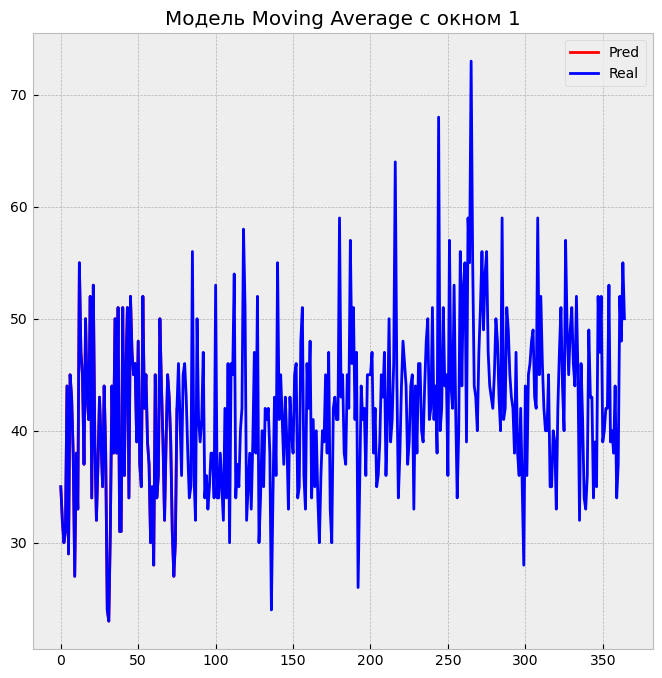

In [246]:
plot_(model=ma_stat,series=female_births['Count'],title=f'Модель Moving Average c окном 1')

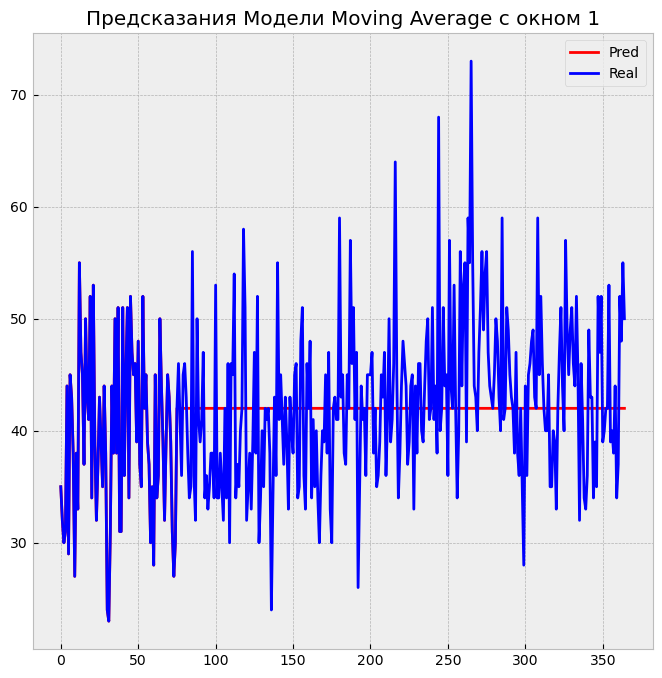

In [247]:
plot_(model=moving_average(series=train_stat,n_window=1,n_preds=len(test_stat)),series=female_births['Count'],title=f'Предсказания Модели Moving Average c окном 1')

#### Для модели WMA

In [262]:
weight_stat = optimize_weights_wma_grad(series=female_births['Count'],n_window=3)

Оптимальные веса: [0.         0.         4.60113294], MSE - 51.29065743944636


In [263]:
wma_stat = moving_average_weight(train_stat, n_window=3,n_preds=len(test_stat),weight=weight_stat)

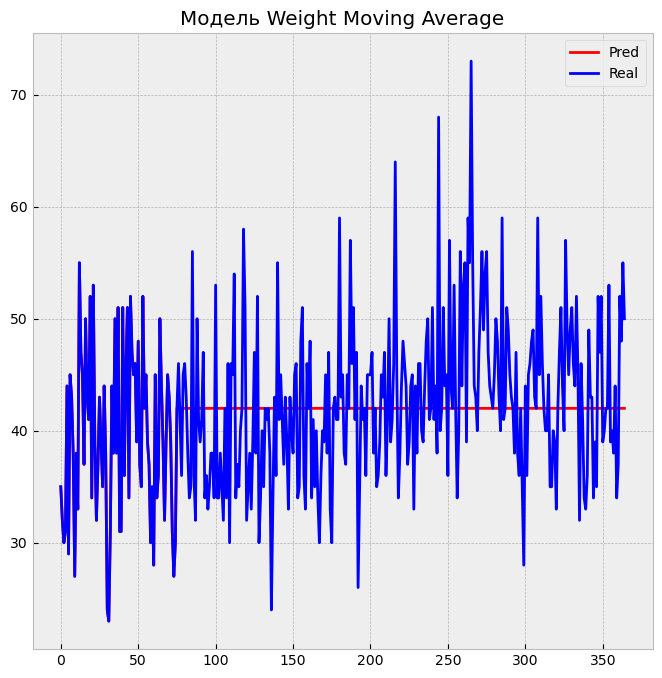

In [264]:
plot_(model = wma_stat,series=female_births['Count'],title='Модель Weight Moving Average')

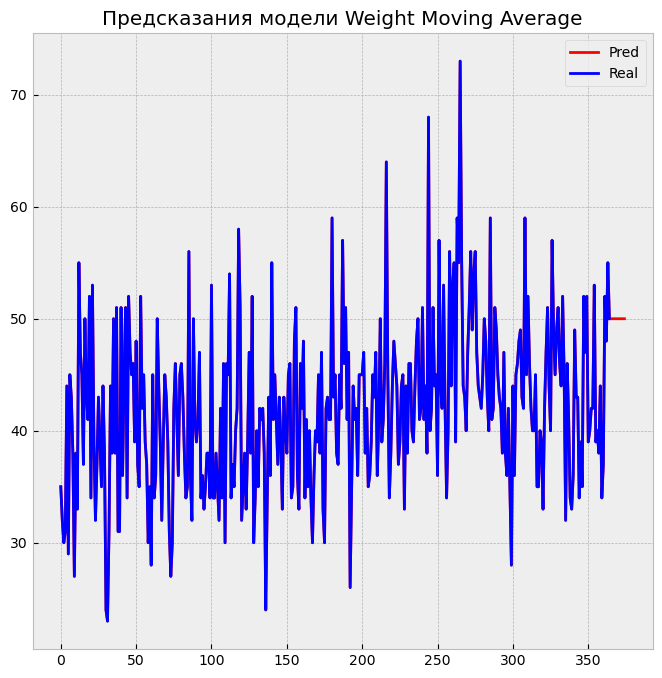

In [265]:
wma_pred_stat = moving_average_weight(female_births['Count'],n_window=3,n_preds=10,weight=weight_stat)
plot_(model=wma_pred_stat,series=female_births['Count'],title='Предсказания модели Weight Moving Average')

#### Для модели EMA

In [266]:
optimize_exp_moving_param(series=female_births['Count'])

Оптимальное значение альфа: [0.03591236], MSE - 65.66799436584685


array([0.03591236])

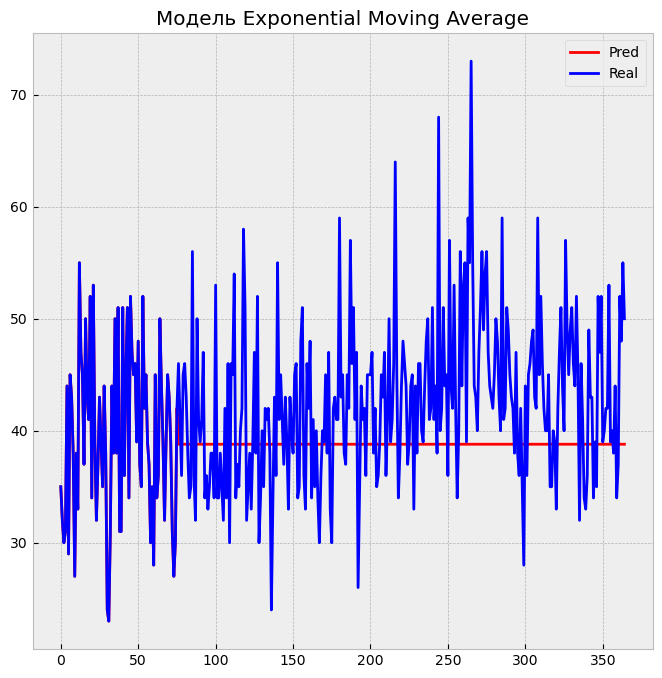

In [268]:
ema_stat = moving_average_exp(series = train_stat,alpha=0.0359,n_preds=len(test_stat))
plot_(ema_stat,female_births['Count'],'Модель Exponential Moving Average')

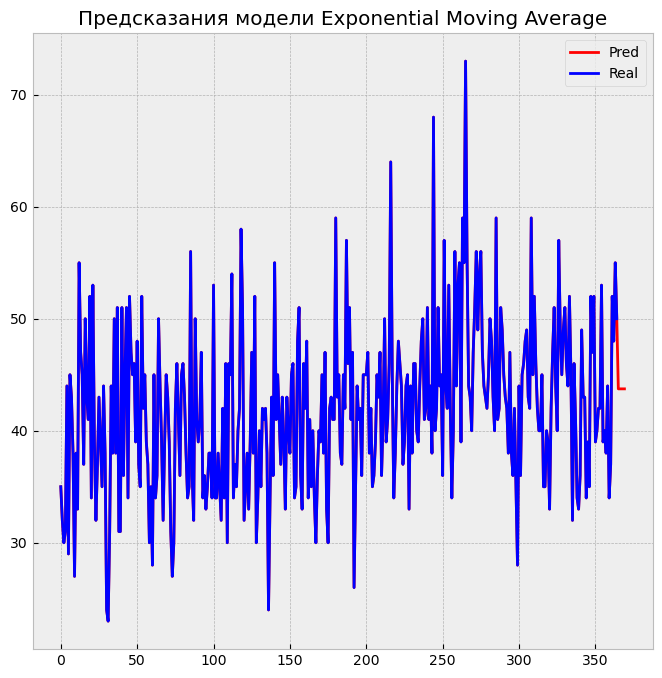

In [273]:
plot_(moving_average_exp(series = female_births['Count'],alpha=0.0359,n_preds=10),female_births['Count'],'Предсказания модели Exponential Moving Average')

Модель достаточно хорошо (точно) предсказывает первые 10 значений, но в конце выходит на плато

#### Для модели DEMA

In [274]:
optimize_double_exp_param(series=female_births['Count'])

Оптимальное значение альфа: 0.8128, оптимальное значение бетта: 0.0554, MSE - 47.765752573926214


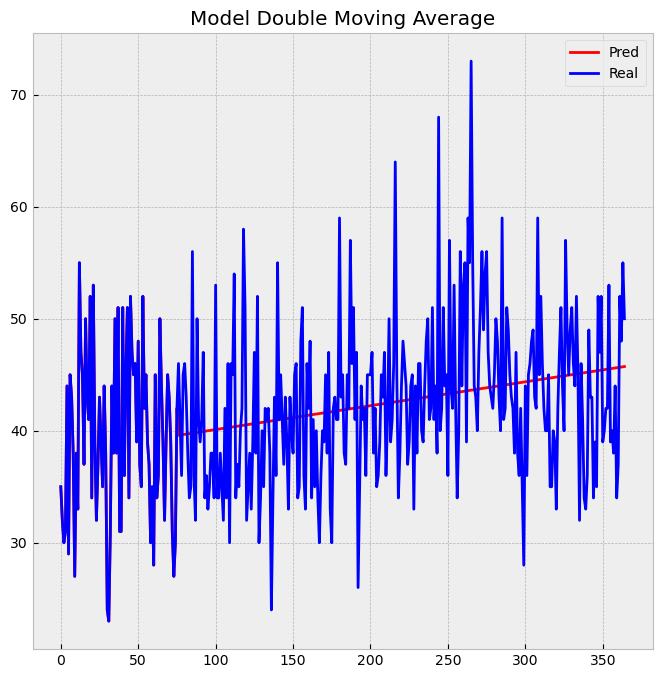

In [276]:
dema_stat = moving_average_dooble_exp(series=train_stat,betta=0.0554,alpha=0.8128,n_preds=len(test_stat))
plot_(model=dema_stat,series=female_births['Count'],title='Model Double Moving Average')

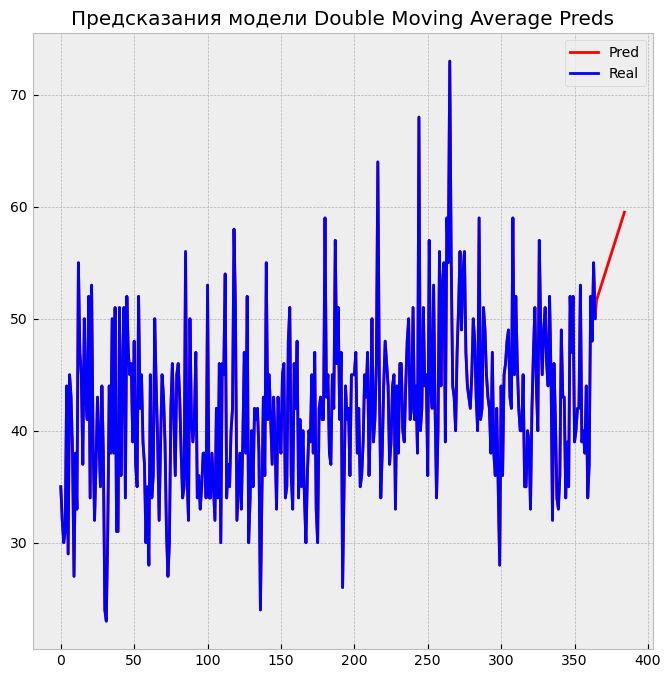

In [279]:
plot_(model=moving_average_dooble_exp(series=female_births['Count'],betta=0.0554,alpha=0.8128,n_preds=20),series=female_births['Count'],title='Предсказания модели Double Moving Average Preds')

Модель так же хорошо предсказывает ряд на первых итерациях

#### Для модели TEMA

In [285]:
optimize_tripple_exp_param(female_births['Count'],n_season=5)

Оптимальное значение альфа: 0.0737, оптимальное значение бетта: 0.0248, оптимальное значение бетта: 0.0101, MSE - 47.54687273894249


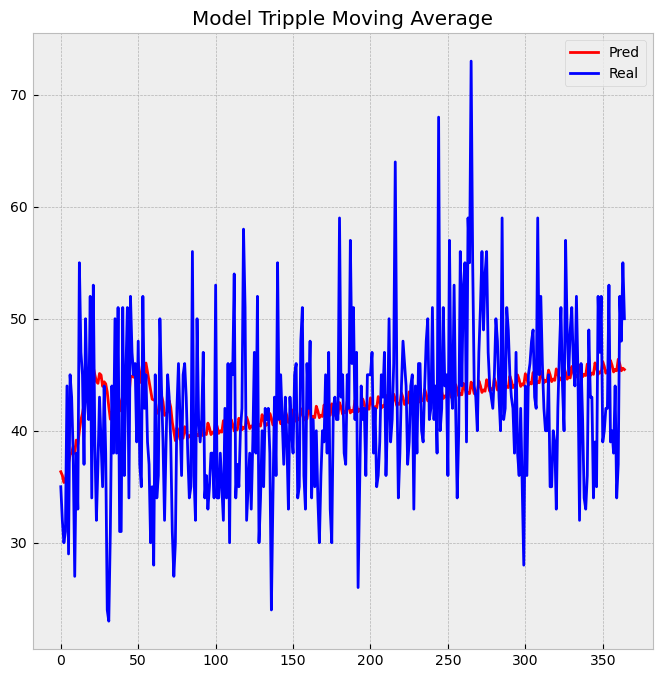

In [287]:
tema_stat = moving_average_tripple_exp(series=train_stat,n_season = 5,alpha=0.0737,beta=0.0248,gamma=0.0101,n_preds=len(test_stat))
plot_(model=tema_stat,series=female_births['Count'],title = 'Model Tripple Moving Average')

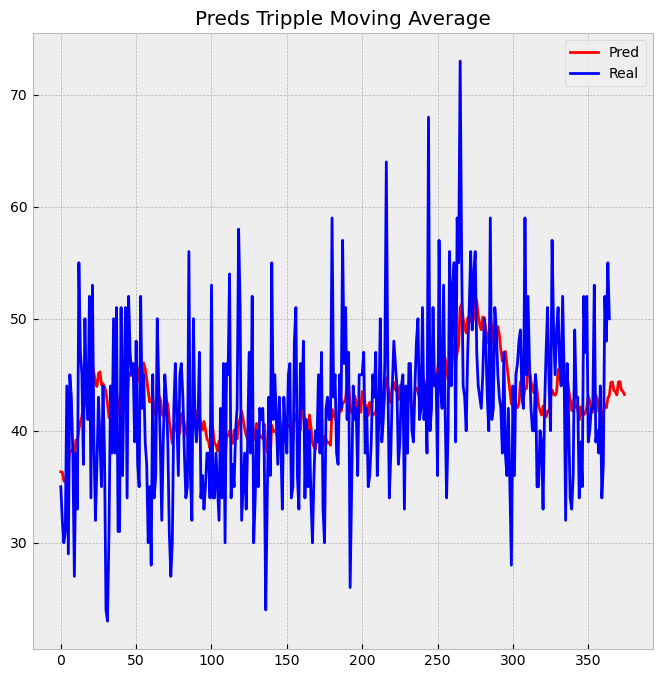

In [290]:
plot_(model=moving_average_tripple_exp(series=female_births['Count'],n_season = 5,alpha=0.0737,beta=0.0248,gamma=0.0101,n_preds=10),series=female_births['Count'],title = 'Preds Tripple Moving Average')

Модель предсказывает ряд, ориентируясь на сезонность, тренд (средний) и уровень, но не учитывает распределение дисперсии. График выше демонстрирует высокую точность предсказания, не учитывая амплитула колебания величины. Для учета амлитуды можно повысить коэффциент альфа

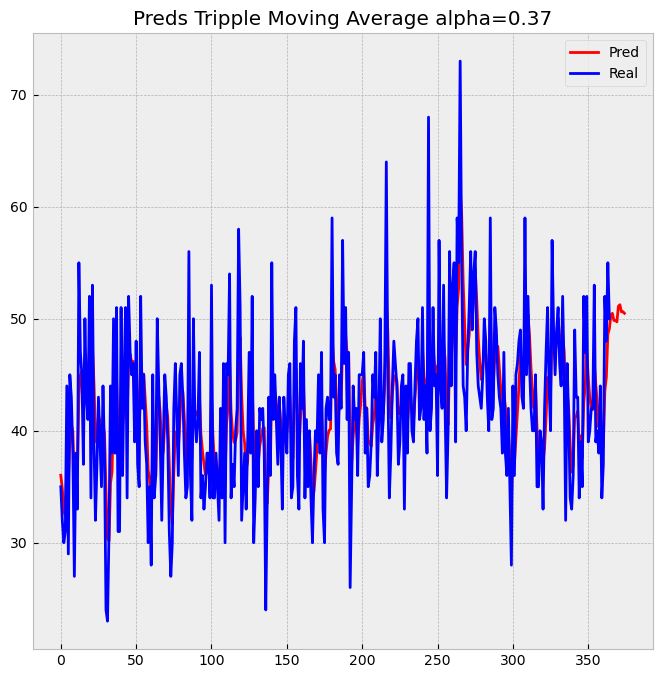

In [292]:
plot_(model=moving_average_tripple_exp(series=female_births['Count'],n_season = 5,alpha=0.37,beta=0.0248,gamma=0.0101,n_preds=10),series=female_births['Count'],title = 'Preds Tripple Moving Average alpha=0.37')

Дальнейшее повышение коэффицента глобально не меняет картинку распределения дисперсии

### Промежуточный вывод по моделям для стационарного ряда

Вывод: в ходе работы были найдены оптимальные параметры для каждой модели - MA,WMA,EMA,DEMA и TEMA - и построены предсказания для стационарного ряда. В связи с чем можно выделить, что лучше всего делает предсказания модель TEMA - она практически "продлевает ряд" согласно сезонности, уровню и тренду ряда, кроме того, данная модель имеет самую низкую ошибку MSE на тестовой выборке среди всех моделей. Однако данная модель не учитывает распределение дисперсии величины, в связи с чем нельзя сказать однозначно, что модель показывает высокую точность в предсказании ряда. Кросс-валидация на выборках стационарного ряда проведена не была.

### Общие выводы

Выводы: в ходе всей работы были обучены модели, описанные выше, на двух рядах - стационарнои и нестационарном. Было экспериментально выяснено, согласно ошибке MSE на тестовой выборке стационарного ряда и тестовой и валидационных выборках, что самую высокую точность среди всех моделей имеет модель TEMA, которая использует тройное экспоненуиальное сглаживание, учитывая влияние тренда, сезонности и уровня. Сглаживание, полученное с помощью всех моделей, для стационарного ряда имеет форму прямой, а не повторяет распределения временного ряда, хотя модели обучались на оптимизированных коэффициентах (например, окно с размером 1 для модели MA должно было повлиять на сглаживание таким образом, чтобы оно повторяло временной ряд - имело повышенную чувствительность, однако в реальности сглаживание имеет низкую чувствительность и превращается в прямую) исходя из чего можно сделать вывод, что стационарные ряды сглаживаются только прямой, то есть для них невозможно сделать  сглаженный ряд с высокой чувтсивтельностью